In [187]:
%pip install statsmodels seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


In [188]:
# Define the industries of GICS classification
gics_industries = {
    "101010": "Energy Equipment & Services",
    "101020": "Oil, Gas & Consumable Fuels",
    "151010": "Chemicals",
    "151020": "Construction Materials",
    "151030": "Containers & Packaging",
    "151040": "Metals & Mining",
    "151050": "Paper & Forest Products",
    "201010": "Aerospace & Defense",
    "201020": "Building Products",
    "201030": "Construction & Engineering",
    "201040": "Electrical Equipment",
    "201050": "Industrial Conglomerates",
    "201060": "Machinery",
    "201070": "Trading Companies & Distributors",
    "202010": "Commercial Services & Supplies",
    "202020": "Professional Services",
    "203010": "Air Freight & Logistics",
    "203020": "Passenger Airlines",
    "203030": "Marine Transportation",
    "203040": "Ground Transportation",
    "203050": "Transportation Infrastructure",
    "251010": "Automobile Components",
    "251020": "Automobiles",
    "252010": "Household Durables",
    "252020": "Leisure Products",
    "252030": "Textiles, Apparel & Luxury Goods",
    "253010": "Hotels, Restaurants & Leisure",
    "253020": "Diversified Consumer Services",
    "255010": "Distributors",
    "255030": "Broadline Retail",
    "255040": "Specialty Retail",
    "301010": "Consumer Staples Distribution & Retail",
    "302010": "Beverages",
    "302020": "Food Products",
    "302030": "Tobacco",
    "303010": "Household Products",
    "303020": "Personal Care Products",
    "351010": "Health Care Equipment & Supplies",
    "351020": "Health Care Providers & Services",
    "351030": "Health Care Technology",
    "352010": "Biotechnology",
    "352020": "Pharmaceuticals",
    "352030": "Life Sciences Tools & Services",
    "401010": "Banks",
    "402010": "Financial Services",
    "402020": "Consumer Finance",
    "402030": "Capital Markets",
    "402040": "Mortgage Real Estate Investment Trusts (REITs)",
    "403010": "Insurance",
    "451020": "IT Services",
    "451030": "Software",
    "452010": "Communications Equipment",
    "452020": "Technology Hardware, Storage & Peripherals",
    "452030": "Electronic Equipment, Instruments & Components",
    "453010": "Semiconductors & Semiconductor Equipment",
    "501010": "Diversified Telecommunication Services",
    "501020": "Wireless Telecommunication Services",
    "502010": "Media",
    "502020": "Entertainment",
    "502030": "Interactive Media & Services",
    "551010": "Electric Utilities",
    "551020": "Gas Utilities",
    "551030": "Multi-Utilities",
    "551040": "Water Utilities",
    "551050": "Independent Power and Renewable Electricity Producers",
    "601010": "Diversified REITs",
    "601025": "Industrial REITs",
    "601030": "Hotel & Resort REITs",
    "601040": "Office REITs",
    "601050": "Health Care REITs",
    "601060": "Residential REITs",
    "601070": "Retail REITs",
    "601080": "Specialized REITs",
    "602010": "Real Estate Management & Development",
    "na" : "Unclassified"
}

In [189]:
# Duplicate stocks in the S&P 500
# duplicate_stocks = { 
#     "50203010" : "GOOGL",
#     "50202010" : "DISCK",
#     "50201020" : "FOXA",
#     "50201040" : "NWSA"
#     }

duplicate_stocks = {}

In [190]:
# Get the industry of a company based on its GICS code
def get_industry(gics_code):
    
    if gics_code == np.nan:
        return "na"
    
    gics_code = str(gics_code)
    if gics_code[:6] in gics_industries:
        return gics_code[:6]
    else:
        return "na"

In [191]:
# Replace column names with actual gics codes
tickers = pd.read_csv('../Data/data_us/tickers.csv', header=None, dtype=str)
tickers.columns = ['ticker', 'gics_code']
tickers.set_index('ticker', inplace=True)

# Assign Industry column to each of the ticker, save n/a for those that are not in the GICS classification
tickers['industry'] = tickers['gics_code'].apply(get_industry)

display(tickers)

,gics_code,industry
ticker,,
0111145D,NaN,na
0202445Q,NaN,na
0203524D,NaN,na
0226226D,NaN,na
0544749D,NaN,na
...,...,...
YUM,25301040,253010
ZBH,35101010,351010
ZBRA,45203010,452030


In [192]:
close_prices = pd.read_csv('../Data/data_us/adjusted.csv')

close_prices['Date'] = pd.to_datetime(close_prices['Date'], format = "%Y%m%d")
close_prices = close_prices.set_index('Date')

# Clean the ticker name with extra space
close_prices.columns = close_prices.columns.str.strip()

# for key, value in duplicate_stocks.items():
#     close_prices.drop(value, axis=1, inplace=True)

display(close_prices.head())

,0111145D,0202445Q,0203524D,0226226D,0544749D,0574018D,0772031D,0848680D,0867887D,0910150D,...,XOM,XRAY,XRX,XTO,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,23.60,42.99,17.6344,46.1555,21.8167,23.1976,3.3329,14.1172,NaN,16.7114,...,20.4223,18.9882,19.3182,12.3424,NaN,8.2905,60.8751,43.5867,40.6011,NaN
2004-01-05,23.72,43.06,18.2824,45.3553,22.2326,23.2143,3.5783,14.6964,NaN,16.8684,...,20.8998,18.6737,19.6451,12.4431,NaN,8.4117,60.3272,43.6667,40.5134,NaN
2004-01-06,23.76,42.50,18.6019,46.5534,22.7548,23.1976,3.5625,15.2842,NaN,16.8880,...,20.7591,18.7034,20.0005,12.2067,NaN,8.6639,60.0315,43.7667,41.0732,NaN
2004-01-07,23.52,43.39,18.3235,46.3323,22.7224,22.9974,3.5150,15.0854,NaN,16.5838,...,20.6083,18.6057,20.0716,12.1498,NaN,8.5155,60.7012,44.5000,40.7899,NaN
2004-01-08,23.36,43.59,19.1678,43.9361,22.6808,22.9807,3.5783,15.3015,NaN,16.7997,...,20.5580,18.7247,20.1284,12.2330,NaN,8.5403,61.8752,44.6000,41.0057,NaN


In [193]:
univ_list = pd.read_csv("../Data/data_us/univ_h.csv")
univ_list['year'] = pd.to_datetime(univ_list['year'], format = "%Y")
univ_list.set_index('year', inplace= True)

close_prices_dict = {}
stocks_list_dict = {}
volatility_dict = {}


for year in univ_list.index.unique():
    stocks_list = univ_list.columns[univ_list.loc[year] == 1].tolist()
    
    # Count the number of stocks in each year
    stocks_list = [stock for stock in stocks_list if stock in close_prices.columns]
    print(f"Year: {year.year} - Number of stocks: {len(stocks_list)}")
    
    stocks_list_dict[year.year] = stocks_list
    close_prices_dict[year.year] = close_prices
    
    temp = close_prices_dict[year.year].loc[str(year.year)]
    
    # Add last month from previous year if present
    if year.year != 2004:
        previous_year_end = close_prices.loc[str(year.year - 1)].tail(30)
        temp = pd.concat([previous_year_end, temp])
    
    # Add first 10 days from next year if present
    if year.year != 2024:
        next_year_start = close_prices.loc[str(year.year + 1)].head(10)
        temp = pd.concat([temp, next_year_start])
        
    close_prices_dict[year.year] = temp


# Filter the stocks from close prices based on the stocks list
for year in univ_list.index.unique():
    stocks_list = stocks_list_dict[year.year]
    close_prices_dict[year.year] = close_prices_dict[year.year][stocks_list]
    
    
display(close_prices_dict[2005].head(10))
display(close_prices_dict[2005].tail(10))
    


Year: 2004 - Number of stocks: 500
Year: 2005 - Number of stocks: 500
Year: 2006 - Number of stocks: 500
Year: 2007 - Number of stocks: 500
Year: 2008 - Number of stocks: 500
Year: 2009 - Number of stocks: 500
Year: 2010 - Number of stocks: 500
Year: 2011 - Number of stocks: 500
Year: 2012 - Number of stocks: 500
Year: 2013 - Number of stocks: 500
Year: 2014 - Number of stocks: 500
Year: 2015 - Number of stocks: 502
Year: 2016 - Number of stocks: 504
Year: 2017 - Number of stocks: 505
Year: 2018 - Number of stocks: 505
Year: 2019 - Number of stocks: 505
Year: 2020 - Number of stocks: 505
Year: 2021 - Number of stocks: 505
Year: 2022 - Number of stocks: 505
Year: 2023 - Number of stocks: 503
Year: 2024 - Number of stocks: 503


,0111145D,0202445Q,0203524D,0226226D,0544749D,0574018D,0772031D,0848680D,0910150D,0961514D,...,WYE,X,XEL,XLNX,XOM,XRX,XTO,YUM,ZBH,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,27.48,48.38,15.4438,54.3080,28.2252,31.4849,3.0796,20.0510,20.4325,27.9102,...,35.5487,38.8733,8.5219,23.3405,25.7685,22.5592,18.1228,10.9721,68.2236,45.9769
2004-11-19,27.27,48.04,15.1060,53.2653,28.6901,31.1046,3.0558,19.8393,20.2159,27.8709,...,35.5666,39.5900,8.4562,22.9297,25.9384,22.2322,18.4792,10.8677,66.9539,45.4603
2004-11-22,27.22,47.97,15.1060,53.1374,29.2593,31.1754,3.0875,19.8569,20.5409,28.1460,...,35.1198,41.3187,8.5266,22.9580,26.2112,22.2891,18.8795,11.0417,68.2149,45.5430
2004-11-23,27.22,47.09,15.1243,52.3997,29.5013,31.7326,3.0479,19.7863,20.5212,28.4080,...,34.9589,40.5513,8.5641,22.5755,26.3605,22.5308,19.3730,11.3126,68.1540,46.0734
2004-11-24,27.37,48.36,14.9691,53.3047,29.7005,32.0156,3.0083,19.7775,20.4818,29.0172,...,35.1466,40.4333,8.5641,22.8022,26.5099,22.5165,19.7184,11.3722,69.3106,46.2938
2004-11-26,27.35,48.56,14.9052,53.0686,29.7859,32.1748,3.0004,20.0157,20.5212,29.0630,...,35.2092,43.2159,8.5970,22.7242,26.5922,22.5308,19.8007,11.3797,69.1802,46.2180
2004-11-29,27.10,48.11,14.5128,51.0422,29.4681,32.1571,3.0162,20.1127,20.4424,28.8993,...,35.4415,43.5954,8.5078,22.4834,26.4481,22.2607,19.6472,11.3349,69.9977,45.4672
2004-11-30,26.89,48.72,14.1111,51.6128,29.5202,32.2809,3.1667,20.1215,20.3439,28.7617,...,35.6292,44.1519,8.4796,22.1151,26.3863,21.7774,19.9323,11.2827,70.9630,45.8047
2004-12-01,26.94,50.20,14.7592,52.9801,29.0042,33.1388,3.2221,20.5979,20.4425,28.6373,...,36.3083,44.0339,8.4890,22.6534,26.3348,21.9337,19.2798,11.6679,72.5718,46.7071


,0111145D,0202445Q,0203524D,0226226D,0544749D,0574018D,0772031D,0848680D,0910150D,0961514D,...,WYE,X,XEL,XLNX,XOM,XRX,XTO,YUM,ZBH,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,31.77,67.38,24.7215,72.2262,45.3967,41.0467,4.4333,20.7887,24.2463,30.6794,...,42.4649,42.0661,9.2326,18.4329,30.7100,21.1946,33.6202,11.7189,59.5532,53.7577
2006-01-04,31.78,67.54,25.2719,71.5360,45.6182,41.3889,4.3146,20.8785,24.0085,30.4790,...,42.4832,42.4064,9.2774,19.2626,30.7626,21.1661,33.3698,11.8191,60.1185,54.1372
2006-01-05,31.63,68.26,25.3453,72.8573,44.8093,41.8735,4.1087,20.7977,24.1075,30.3407,...,42.7937,43.5466,9.2724,20.4214,30.6102,20.9387,33.1342,12.3230,59.4837,54.6292
2006-01-06,31.87,66.82,25.6663,72.9559,45.4160,42.6529,4.2829,20.8875,24.9597,30.4493,...,43.6156,43.5381,9.3072,20.8291,31.2143,20.8108,33.8412,12.2879,59.1793,55.1986
2006-01-09,32.06,67.84,26.2350,77.1662,44.9489,42.9380,4.3304,20.7708,24.6129,30.4073,...,43.3964,43.9465,9.2823,20.8076,31.1985,21.0950,33.5466,12.3831,61.2751,54.7417
2006-01-10,31.96,67.70,26.0608,77.4029,45.8060,43.3941,4.3462,20.6900,24.8408,30.2671,...,43.6613,43.6742,9.3271,20.9221,31.4401,20.9813,33.5539,12.3731,61.0142,54.1021
2006-01-11,31.99,68.85,26.3726,77.8367,47.2120,43.7458,4.5283,20.6900,25.0290,30.0288,...,43.3508,42.6447,9.2575,20.7862,31.6554,21.4931,33.2741,12.2739,62.6057,54.4184
2006-01-12,31.79,68.32,25.9048,75.7168,46.2972,43.8788,4.5283,20.4565,24.7714,29.8816,...,43.5060,42.1512,9.3519,20.6074,31.3245,21.8058,33.2225,12.0754,62.9796,53.5960
2006-01-13,31.96,68.07,25.1985,76.0323,46.1768,42.9760,4.5758,20.9683,24.6426,30.0778,...,44.0905,42.6447,9.3569,20.5931,32.0231,21.3225,33.5834,12.0729,61.3969,54.1513


In [194]:
volatility_dict = {}
five_day_return_dict = {}
norm_five_day_return_dict = {}
industry_v_dict = {}
returns_minus_industry_dict = {}
industry_returns_dict = {}
beta_dict = {}
ranked_beta_dict = {}
rsquared_dict = {}
ranked_rsquared_dict = {}
ranked_norm_five_day_return_dict = {}
industry_ranked_v_dict = {}

for year in close_prices_dict.keys():
    if year == 2004:
        continue
    else:
        # Calculate the volatility by constructing a rolling window of 21 days
        volatility_dict[year] = (np.log(close_prices_dict[year]).diff(1).fillna(0)).rolling(window=21).std()
        
        # Set the minimum volatility to 0.005
        volatility_dict[year] = volatility_dict[year].applymap(lambda x: max(0.005, x))
        
        # Calculate the normalized 5-day return
        five_day_return_dict[year] = (np.log(close_prices_dict[year]).diff(5).fillna(0))
        norm_five_day_return_dict[year] = five_day_return_dict[year] / volatility_dict[year]
        
        # Calculate the returns minus the industry average
        returns_minus_industry_dict[year] = (np.log(close_prices_dict[year]).diff(1).fillna(0))
        
        ranks = norm_five_day_return_dict[year].rank(axis=1, method = 'first', ascending=False)
        N = ranks.shape[1]
        
        # Redefine the factor in terms of the rank
        ranked_norm_five_day_return_dict[year] = (N + 1 - 2 * ranks) / (N - 1)
        # display(ranked_norm_five_day_return_dict[year].head())
        
        industry_v_dict[year] = {}
        industry_returns_dict[year] = {}
        industry_ranked_v_dict[year] = {}
        
        for key, value in gics_industries.items():
            mask = tickers[tickers['industry'] == key].index
            mask = [ticker for ticker in mask if ticker in norm_five_day_return_dict[year].columns]

            if mask:
                
                industry_v_dict[year][key] = norm_five_day_return_dict[year].loc[:, mask].mean(axis=1)
                industry_returns_dict[year][key] = returns_minus_industry_dict[year].loc[:, mask].mean(axis=1)
                industry_ranked_v_dict[year][key] = ranked_norm_five_day_return_dict[year].loc[:, mask].mean(axis=1)

                # subtract the industry average from the stock return
                norm_five_day_return_dict[year].loc[:, mask] = norm_five_day_return_dict[year].loc[:, mask].sub(industry_v_dict[year][key], axis=0)
                
                ranked_norm_five_day_return_dict[year].loc[:, mask] = ranked_norm_five_day_return_dict[year].loc[:, mask].sub(industry_ranked_v_dict[year][key], axis=0)

                # Subtract the industry returns
                returns_minus_industry_dict[year].loc[:, mask] = returns_minus_industry_dict[year].loc[:, mask].sub(industry_returns_dict[year][key], axis=0)

        norm_five_day_return = norm_five_day_return_dict[year].loc[str(year)]
        ranked_norm_five_day_return = ranked_norm_five_day_return_dict[year].loc[str(year)]
        returns_minus_industry = returns_minus_industry_dict[year].shift(-1).loc[str(year)]
        
            
        beta_dict[year] = {}
        rsquared_dict[year] = {}
        ranked_beta_dict[year] = {}
        ranked_rsquared_dict[year] = {}
        
        for t in norm_five_day_return.index:
            # Dependent variable: returns at time t+1
            R_t1 = returns_minus_industry.loc[t]
            
            # Independent variable: factors at time t
            v_t = norm_five_day_return.loc[t]
            
            ranked_v_t = ranked_norm_five_day_return.loc[t]
            
             # Calculate beta(t)
            beta_t = (R_t1 * v_t).sum() / (v_t * v_t).sum()
            beta_dict[year][t] = beta_t
            
            ranked_beta_t = (R_t1 * ranked_v_t).sum() / (ranked_v_t * ranked_v_t).sum()
            ranked_beta_dict[year][t] = ranked_beta_t
            
            
            # Calculate residuals
            epsilon_t = R_t1 - beta_t * v_t
            ranked_epsilon_t = R_t1 - ranked_beta_t * ranked_v_t
            
            # Calculate R^2(t)
            rsquared_t = 1 - (epsilon_t ** 2).sum() / (R_t1 * R_t1).sum()
            rsquared_dict[year][t] = rsquared_t
            
            ranked_rsquared_t = 1 - (ranked_epsilon_t ** 2).sum() / (R_t1 * R_t1).sum()
            ranked_rsquared_dict[year][t] = ranked_rsquared_t
            
            
        # Convert the dictionaries to dataframes
        beta_dict[year] = pd.Series(beta_dict[year])
        rsquared_dict[year] = pd.Series(rsquared_dict[year])
        ranked_beta_dict[year] = pd.Series(ranked_beta_dict[year])
        ranked_rsquared_dict[year] = pd.Series(ranked_rsquared_dict[year])
        
# drop last row for 2024 from beta list
beta_dict[2024] = beta_dict[2024].iloc[:-1]
rsquared_dict[2024] = rsquared_dict[2024].iloc[:-1]
ranked_beta_dict[2024] = ranked_beta_dict[2024].iloc[:-1]
ranked_rsquared_dict[2024] = ranked_rsquared_dict[2024].iloc[:-1]


In [195]:
print("Beta")
display(beta_dict[2005].head())
display(beta_dict[2024].tail())

print("R-squared")
display(rsquared_dict[2005].head())
display(rsquared_dict[2024].tail())

print("Ranked Beta")
display(ranked_beta_dict[2005].head())
display(ranked_beta_dict[2024].tail())

print("Ranked R-squared")
display(ranked_rsquared_dict[2005].head())
display(ranked_rsquared_dict[2024].tail())


Beta


2005-01-03   -0.000937
2005-01-04   -0.000515
2005-01-05   -0.000620
2005-01-06    0.000143
2005-01-07   -0.000175
dtype: float64

2024-12-23   -0.000377
2024-12-24    0.000099
2024-12-26   -0.000202
2024-12-27    0.000612
2024-12-30   -0.000028
dtype: float64

R-squared


2005-01-03    0.007912
2005-01-04    0.002367
2005-01-05    0.005109
2005-01-06    0.000528
2005-01-07    0.001344
dtype: float64

...

2005-01-03   -0.002531
2005-01-04   -0.001855
2005-01-05   -0.001968
2005-01-06    0.000166
2005-01-07   -0.000379
dtype: float64

2024-12-23   -0.001574
2024-12-24    0.000404
2024-12-26   -0.000584
2024-12-27    0.001382
2024-12-30    0.000213
dtype: float64

Ranked R-squared


2005-01-03    0.009239
2005-01-04    0.004733
2005-01-05    0.005826
2005-01-06    0.000063
2005-01-07    0.000462
dtype: float64

2024-12-23    0.017213
2024-12-24    0.000959
2024-12-26    0.003141
2024-12-27    0.010255
2024-12-30    0.000282
dtype: float64

In [196]:
summary_df = pd.DataFrame(columns=['Year', 'avg_beta', 't_stat', 'T'])

for year in beta_dict.keys():
    avg_beta = beta_dict[year].mean()
    T = len(beta_dict[year])
    t_stat = np.sqrt(T) * avg_beta / beta_dict[year].std()
    
    
    summary_df.loc[len(summary_df)] = [str(year), avg_beta, t_stat, T]

summary_df.set_index('Year', inplace=True)
display(summary_df)

,avg_beta,t_stat,T
Year,,,
2005,-0.000072,-1.684675,252
2006,-0.000104,-2.459836,251
2007,-0.000074,-1.174053,251
2008,-0.000431,-1.536899,253
2009,-0.000118,-0.876166,252
2010,-0.000052,-1.073549,252
2011,-0.000186,-2.247070,252
2012,0.000043,1.034030,250
2013,-0.000057,-1.631274,252


In [197]:
ranked_summary_df = pd.DataFrame(columns=['Year', 'avg_beta', 't_stat', 'T'])

for year in ranked_beta_dict.keys():
    avg_beta = ranked_beta_dict[year].mean()
    T = len(ranked_beta_dict[year])
    t_stat = np.sqrt(T) * avg_beta / ranked_beta_dict[year].std()
    
    
    ranked_summary_df.loc[len(ranked_summary_df)] = [str(year), avg_beta, t_stat, T]

ranked_summary_df.set_index('Year', inplace=True)
display(ranked_summary_df)

,avg_beta,t_stat,T
Year,,,
2005,-0.000259,-2.039527,252
2006,-0.000404,-3.139695,251
2007,-0.000217,-1.047649,251
2008,-0.000967,-1.484470,253
2009,-0.000071,-0.204938,252
2010,-0.000157,-1.212729,252
2011,-0.000337,-1.802506,252
2012,0.000058,0.444774,250
2013,-0.000209,-1.981549,252


In [198]:
expected_returns_dict = {}
portfolio_returns_dict = {}
portfolio_returns_wc_dict = {}
cost = 0.0005

for year in range(2006, 2025):
    previous_year = str(year - 1)
    expected_returns_dict[year] = summary_df.loc[previous_year, 'avg_beta'] * norm_five_day_return_dict[year]
    expected_returns_dict[year] = expected_returns_dict[year].shift(1)
    expected_returns_dict[year] = expected_returns_dict[year].loc[str(year)]
    
    portfolio_returns_dict[year] = {}
    portfolio_returns_wc_dict[year] = {}
    
    returns = np.log(close_prices_dict[year]).diff(1).fillna(0)
    
    prev_top_20 = []
    prev_bottom_20 = []
    
    for t in expected_returns_dict[year].index:
        
        n = int(len(expected_returns_dict[year].loc[t]) * 0.2)
        # Find top 20% of stocks
        top_20 = expected_returns_dict[year].loc[t].nlargest(n).index.tolist()
        
        # Find bottom 20% of stocks
        bottom_20 = expected_returns_dict[year].loc[t].nsmallest(n).index.tolist()
        
        portfolio_returns_dict[year][t] = returns[top_20].loc[t].mean() - returns[bottom_20].loc[t].mean()
        
        changed_long_portfolio = list((set(prev_top_20) - set(top_20)).union(set(top_20) - set(prev_top_20)))
        changed_short_portfolio = list((set(prev_bottom_20) - set(bottom_20)).union(set(bottom_20) - set(prev_bottom_20)))
        
        
        portfolio_returns_wc_dict[year][t] = portfolio_returns_dict[year][t] - (cost*len(changed_long_portfolio)/n) - (cost*len(changed_short_portfolio)/n)
        
        prev_top_20 = top_20
        prev_bottom_20 = bottom_20
        
    portfolio_returns_dict[year] = pd.DataFrame.from_dict(portfolio_returns_dict[year], orient='index', columns=['portfolio_returns'])
    portfolio_returns_dict[year].index = pd.to_datetime(portfolio_returns_dict[year].index)
    portfolio_returns_dict[year] = portfolio_returns_dict[year].loc[str(year)]
    
    portfolio_returns_wc_dict[year] = pd.DataFrame.from_dict(portfolio_returns_wc_dict[year], orient='index', columns=['portfolio_returns_with_costs'])
    portfolio_returns_wc_dict[year].index = pd.to_datetime(portfolio_returns_wc_dict[year].index)
    portfolio_returns_wc_dict[year] = portfolio_returns_wc_dict[year].loc[str(year)]
       
    


In [199]:
display(expected_returns_dict[2006].head())

,0111145D,0202445Q,0203524D,0226226D,0544749D,0574018D,0772031D,0848680D,0910150D,0961514D,...,WYE,X,XEL,XLNX,XOM,XRX,XTO,YUM,ZBH,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.000133,0.000026,0.000057,-0.000090,-0.000010,-0.000033,-0.000101,0.000124,-0.000245,-0.000008,...,-0.000017,-0.000063,0.000053,0.000035,0.000019,-0.000042,0.000091,0.000209,-0.000020,-0.000031
2006-01-04,-0.000145,-0.000057,0.000007,-0.000190,-0.000115,-0.000175,0.000031,0.000274,-0.000249,-0.000027,...,0.000086,0.000003,0.000090,0.000017,-0.000018,-0.000006,0.000012,0.000264,-0.000045,-0.000038
2006-01-05,-0.000119,-0.000094,-0.000135,-0.000018,-0.000204,-0.000124,0.000268,0.000318,-0.000127,0.000142,...,0.000154,0.000118,0.000030,-0.000104,-0.000023,0.000044,-0.000057,0.000130,0.000006,-0.000045
2006-01-06,-0.000129,-0.000137,-0.000146,-0.000113,-0.000039,-0.000227,0.000322,0.000283,-0.000221,0.000140,...,0.000094,-0.000039,0.000065,-0.000177,-0.000071,0.000060,0.000015,-0.000108,0.000043,-0.000027
2006-01-09,-0.000168,0.000032,-0.000188,-0.000039,-0.000078,-0.000330,0.000243,0.000271,-0.000087,0.000135,...,-0.000067,0.000033,0.000054,-0.000156,-0.000063,0.000178,-0.000045,-0.000093,0.000165,-0.000072


In [200]:
display(portfolio_returns_dict[2006].head())
display(portfolio_returns_dict[2024].tail())

,portfolio_returns
2006-01-03,0.009026
2006-01-04,0.005588
2006-01-05,0.001461
2006-01-06,0.003423
2006-01-09,-0.001455


,portfolio_returns
2024-12-24,0.001869
2024-12-26,-0.000501
2024-12-27,0.000987
2024-12-30,-0.001329
2024-12-31,-0.000113


In [201]:
display(portfolio_returns_wc_dict[2006].head())
display(portfolio_returns_wc_dict[2024].tail())

,portfolio_returns_with_costs
2006-01-03,0.008026
2006-01-04,0.004588
2006-01-05,0.000571
2006-01-06,0.002623
2006-01-09,-0.002065


,portfolio_returns_with_costs
2024-12-24,0.001259
2024-12-26,-0.001101
2024-12-27,0.000327
2024-12-30,-0.002099
2024-12-31,-0.001113


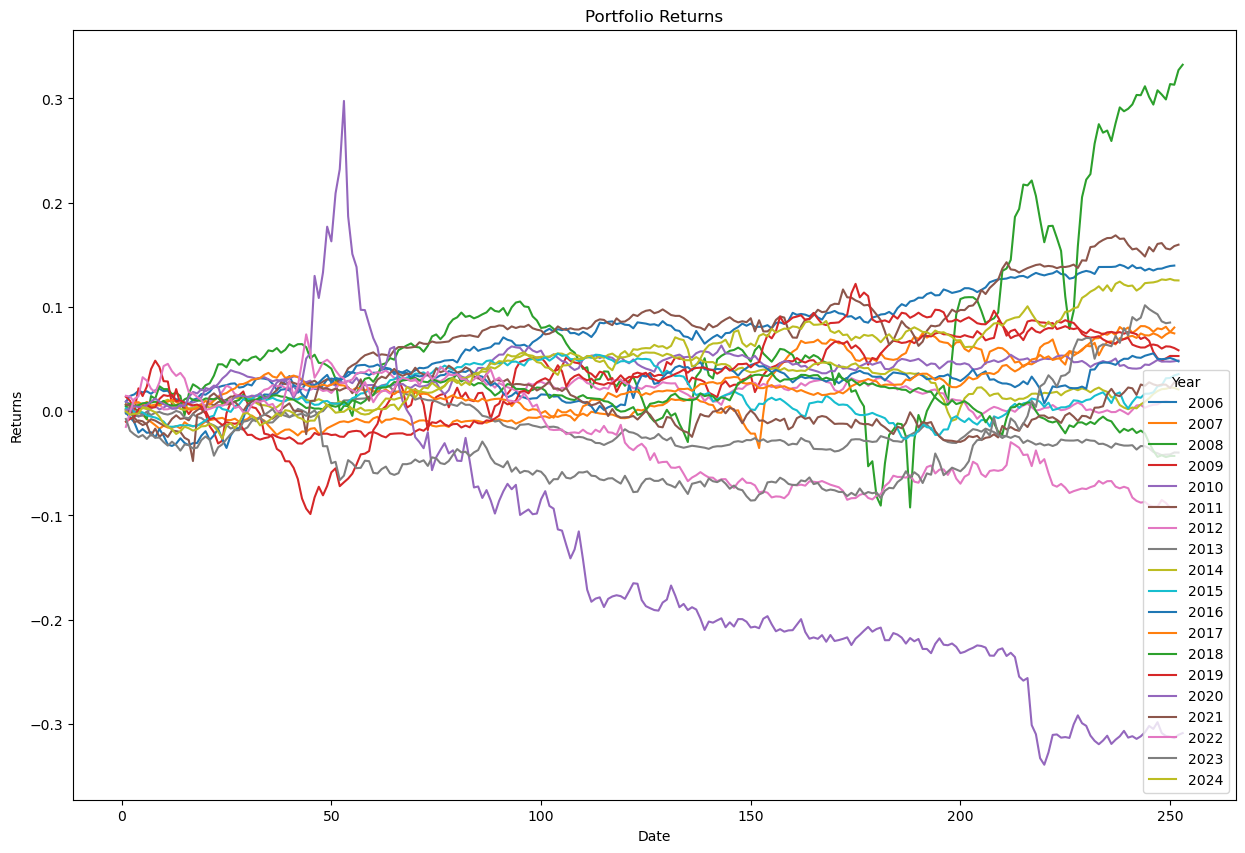

In [202]:
results = pd.DataFrame(columns=['Year', 'Returns', 'Annualized Volatility', 'Sharpe Ratio'])

plt.figure(figsize=(15, 10))
plt.title("Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Returns")

for year in portfolio_returns_dict.keys():
    returns = portfolio_returns_dict[year]['portfolio_returns'].cumsum()
    
    T = summary_df.loc[str(year), "T"]
    results.loc[len(results)] = [
        str(year), 
        returns.iloc[-1], 
        portfolio_returns_dict[year]['portfolio_returns'].std() * np.sqrt(T), 
        np.sqrt(T) * portfolio_returns_dict[year]['portfolio_returns'].mean() / portfolio_returns_dict[year]['portfolio_returns'].std()
    ]
    
    # Plot number of days in a year vs returns
    plt.plot(range(1, len(returns)+1), returns.values, label=year)

results.set_index('Year', inplace=True)

plt.legend(title="Year")
plt.show()

In [203]:
min_index = results['Returns'].idxmin()
max_index = results['Returns'].idxmax()

print(f"The best year is {max_index} with a return of {results.loc[max_index, 'Returns']}")
print(f"The worst year is {min_index} with a return of {results.loc[min_index, 'Returns']}")

display(results)

The best year is 2008 with a return of 0.33240185530972866
The worst year is 2020 with a return of -0.3088560063488792


,Returns,Annualized Volatility,Sharpe Ratio
Year,,,
2006,0.139695,0.046891,2.979113
2007,0.080245,0.072921,1.100447
2008,0.332402,0.224860,1.478259
2009,0.052902,0.121110,0.436807
2010,0.048564,0.048088,1.009895
2011,0.159739,0.064274,2.485297
2012,0.008800,0.047775,0.184188
2013,-0.039738,0.037707,-1.053866
2014,0.020816,0.042558,0.489129


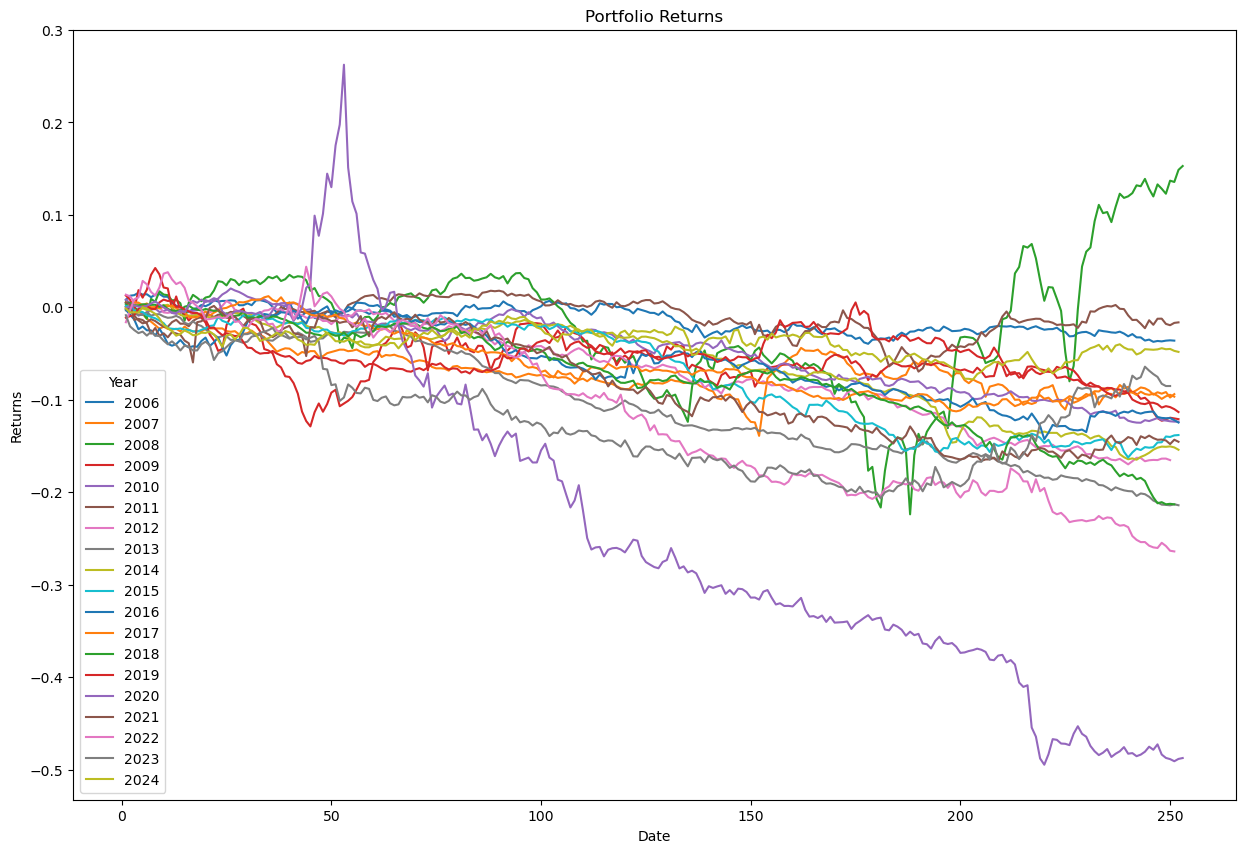

In [204]:
results_with_costs = pd.DataFrame(columns=['Year', 'Returns', 'Annualized Volatility', 'Sharpe Ratio'])

plt.figure(figsize=(15, 10))
plt.title("Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Returns")

for year in portfolio_returns_wc_dict.keys():
    returns_with_costs = portfolio_returns_wc_dict[year]['portfolio_returns_with_costs'].cumsum()
    
    T = summary_df.loc[str(year), "T"]
    results_with_costs.loc[len(results_with_costs)] = [
        str(year), 
        returns_with_costs.iloc[-1], 
        portfolio_returns_wc_dict[year]['portfolio_returns_with_costs'].std() * np.sqrt(T), 
        np.sqrt(T) * portfolio_returns_wc_dict[year]['portfolio_returns_with_costs'].mean() / portfolio_returns_wc_dict[year]['portfolio_returns_with_costs'].std()
    ]
    
    # Plot number of days in a year vs returns
    plt.plot(range(1, len(returns_with_costs)+1), returns_with_costs.values, label=year)

results_with_costs.set_index('Year', inplace=True)

plt.legend(title="Year")
plt.show()

In [205]:
min_index = results_with_costs['Returns'].idxmin()
max_index = results_with_costs['Returns'].idxmax()

print(f"The best year is {max_index} with a return of {results_with_costs.loc[max_index, 'Returns']}")
print(f"The worst year is {min_index} with a return of {results_with_costs.loc[min_index, 'Returns']}")

display(results_with_costs)

The best year is 2008 with a return of 0.1529018553097287
The worst year is 2020 with a return of -0.48753917466571084


,Returns,Annualized Volatility,Sharpe Ratio
Year,,,
2006,-0.036005,0.047027,-0.765620
2007,-0.093875,0.072986,-1.286197
2008,0.152902,0.224640,0.680653
2009,-0.120928,0.121116,-0.998449
2010,-0.123666,0.048225,-2.564333
2011,-0.016241,0.064441,-0.252030
2012,-0.165250,0.047751,-3.460676
2013,-0.214078,0.037807,-5.662420
2014,-0.154044,0.042484,-3.625916
